##1. Subir el archivo directamente a Colab

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Superstore.xlsx to Superstore (1).xlsx


In [9]:
import pandas as pd

df = pd.read_excel('Superstore.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##2. Explorar los datos

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##3. Limpiar datos si hace falta

In [49]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

In [14]:
df.duplicated().any()

np.False_

**4. Análisis exporatorio (EDA)**

##4.1 Indicadores de ventas

In [50]:
# Ventas por categoría
ventas_categoria = df.groupby('Category')['Sales'].sum()
ventas_categoria = ventas_categoria.sort_values(ascending=False)
print("📊 Ventas por Categoría")
print(ventas_categoria)
print("\n")

# Ventas por región
ventas_region = df.groupby('Region')['Sales'].sum()
ventas_region = ventas_region.sort_values(ascending=False)
print("📊 Ventas por Región")  # Título arriba
print(ventas_region)

📊 Ventas por Categoría
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


📊 Ventas por Región
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [29]:
total_ventas = df['Sales'].sum()
total_ventas = round(total_ventas, 2)

ventas_promedio = df['Sales'].mean()
ventas_promedio = round(ventas_promedio, 2)

print("Ventas totales:", total_ventas)
print("Venta promedio por pedido:", ventas_promedio)
print("Venta máxima:", df['Sales'].max())
print("Venta mínima:", df['Sales'].min())

Ventas totales: 2297200.86
Venta promedio por pedido: 229.86
Venta máxima: 22638.48
Venta mínima: 0.444


#4.2 Ticket promedio y ganancia por categoría y región

In [47]:
ventas_region_prom = df.groupby('Region')['Sales'].mean().sort_values(ascending=False)
ventas_region_prom = round(ventas_region_prom, 2)
print("venta promedio por región:")
print(ventas_region_prom)
print("\n")

ganancia_categoria_region = df.groupby(['Category', 'Region'])['Profit'].mean()
ganancia_categoria_region = round(ganancia_categoria_region, 2)
print("Ganancia promedio por categoría y región:")
print(ganancia_categoria_region)

venta promedio por región:
Region
South      241.80
East       238.34
West       226.49
Central    215.77
Name: Sales, dtype: float64


Ganancia promedio por categoría y región:
Category         Region 
Furniture        Central    -5.97
                 East        5.07
                 South      20.40
                 West       16.27
Office Supplies  Central     6.24
                 East       23.96
                 South      20.09
                 West       27.73
Technology       Central    80.23
                 East       88.71
                 South      68.23
                 West       73.96
Name: Profit, dtype: float64


##4.3 Indicadores de cantidad y productos

In [54]:
total_cantidad = df['Quantity'].sum()
print("Cantidad total de productos vendidos:", total_cantidad)
print("\n")
cantidad_promedio = df['Quantity'].mean()
cantidad_promedio = round(cantidad_promedio, 0)
print("Cantidad promedio por pedido:", cantidad_promedio)
print("\n")
productos_top = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 productos más vendidos:")
print(productos_top)

Cantidad total de productos vendidos: 37873


Cantidad promedio por pedido: 4.0


Top 10 productos más vendidos:
Product Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64


##4.4 Indicadores de rentabilidad

In [58]:
profit_total = df['Profit'].sum()
profit_total = round(profit_total, 2)
print("Ganancia total:", profit_total)

df['Profit_Margin'] = df['Profit'] / df['Sales']
margen_promedio = df['Profit_Margin'].mean()
margen_promedio = round(margen_promedio*100, 2)
print("Margen promedio:",f"{margen_promedio}%")

perdidas = df[df['Profit'] < 0].shape[0]
total_pedidos = df.shape[0]
porcentaje_perdidas = (perdidas / total_pedidos) * 100
print("Cantidad de pedidos con pérdida:", perdidas)
print("Porcentaje de pedidos con pérdida:", round(porcentaje_perdidas,2), "%")

Ganancia total: 286397.02
Margen promedio: 12.03%
Cantidad de pedidos con pérdida: 1871
Porcentaje de pedidos con pérdida: 18.72 %


##4.5 Descuentos y promociones

In [40]:
descuento_promedio = df['Discount'].mean()
descuento_promedio = round(descuento_promedio*100, 2)
print("Descuento promedio:", f"{descuento_promedio}%")

pedidos_descuento_alto = df[df['Discount'] > 0.2].shape[0] #Descuentos mayor al 20%
print("Pedidos con descuento alto:", pedidos_descuento_alto)

Descuento promedio: 15.62%
Pedidos con descuento alto: 1393


##5. Visualizaciones básicas

##5.1. Ventas por región

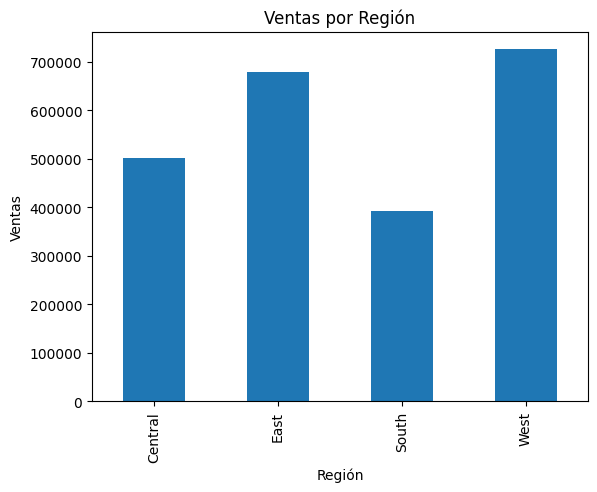

In [48]:
import matplotlib.pyplot as plt

ventas_region = df.groupby('Region')['Sales'].sum()

plt.figure()
ventas_region.plot(kind='bar')

plt.title("Ventas por Región")
plt.ylabel("Ventas")
plt.xlabel("Región")

plt.show()

##5.2 Ventas por categoría

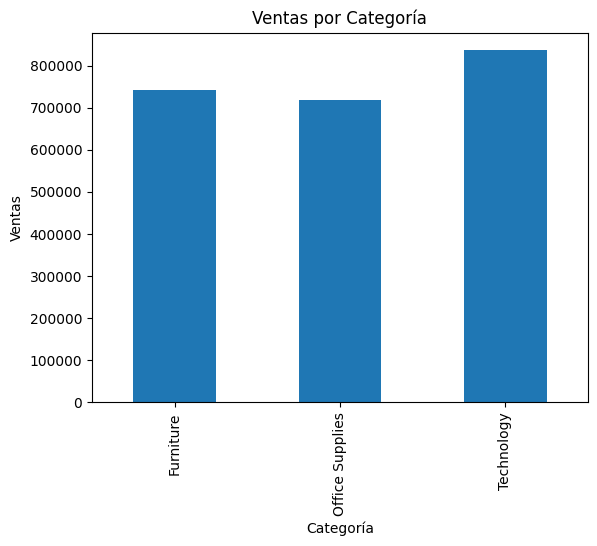

In [51]:
ventas_categoria = df.groupby('Category')['Sales'].sum()

plt.figure()
ventas_categoria.plot(kind='bar')

plt.title("Ventas por Categoría")
plt.ylabel("Ventas")
plt.xlabel("Categoría")

plt.show()

##5.3 Ganancia por categoría

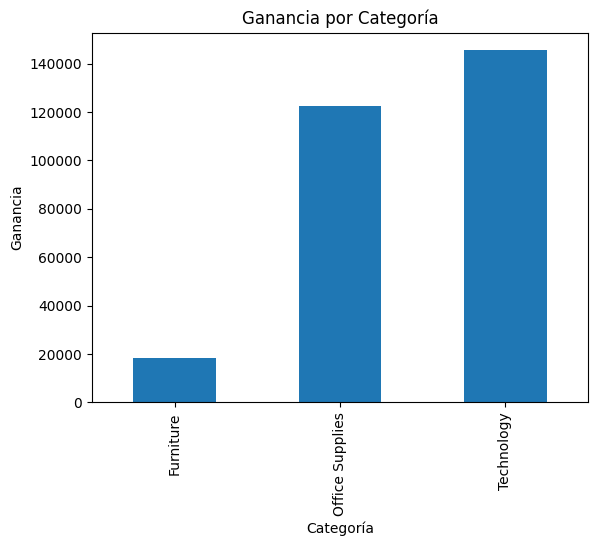

In [52]:
ganancia_categoria = df.groupby('Category')['Profit'].sum()

plt.figure()
ganancia_categoria.plot(kind='bar')

plt.title("Ganancia por Categoría")
plt.ylabel("Ganancia")
plt.xlabel("Categoría")

plt.show()

##5.4 Top 10 Productos con más ventas

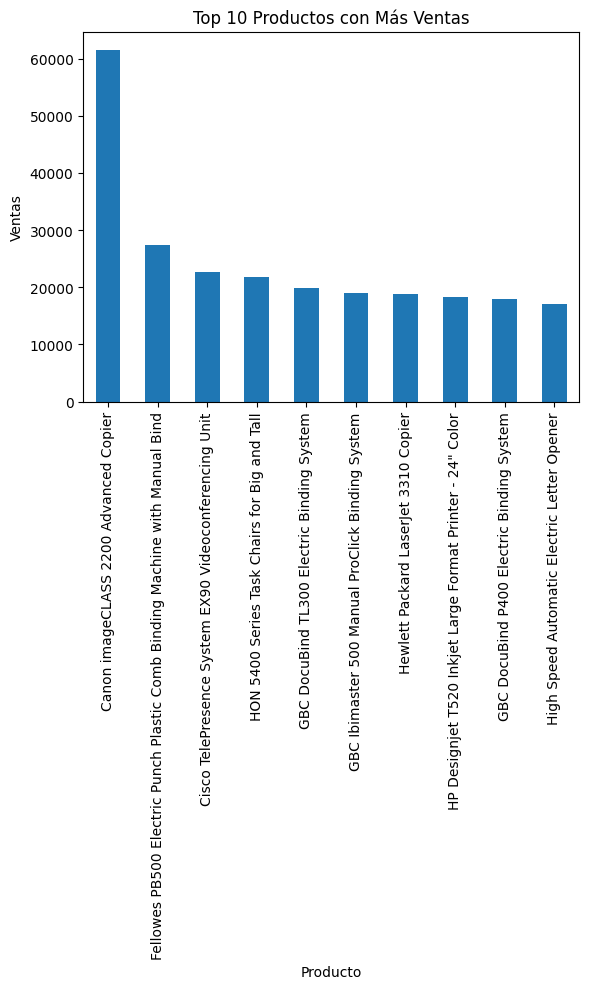

In [53]:
top_productos = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_productos.plot(kind='bar')

plt.title("Top 10 Productos con Más Ventas")
plt.ylabel("Ventas")
plt.xlabel("Producto")

plt.show()

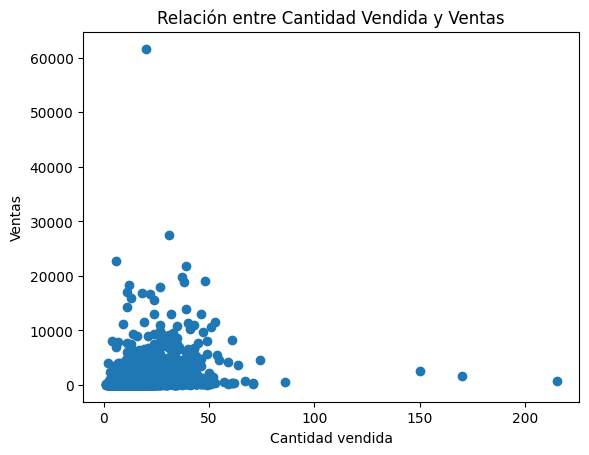

In [60]:
ventas_cantidad = df.groupby('Product Name')[['Sales','Quantity']].sum()

plt.figure()

plt.scatter(ventas_cantidad['Quantity'], ventas_cantidad['Sales'])

plt.title("Relación entre Cantidad Vendida y Ventas")
plt.xlabel("Cantidad vendida")
plt.ylabel("Ventas")

plt.show()

##6. Análisis kpis

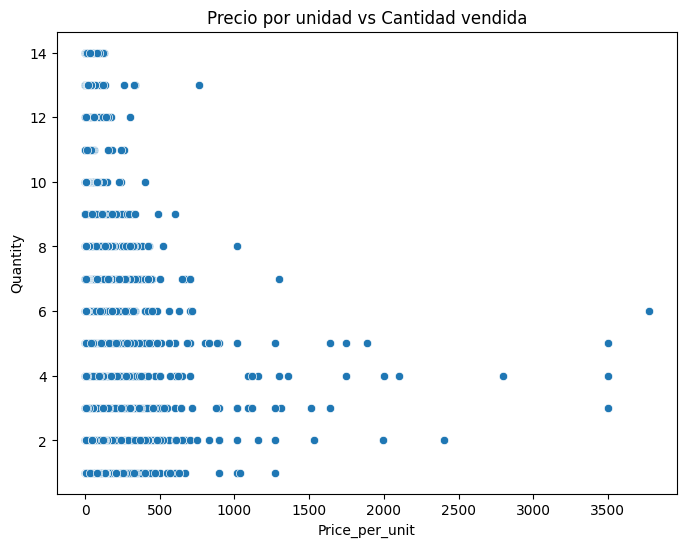

In [55]:
df['Price_per_unit'] = df['Sales'] / df['Quantity']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Price_per_unit', y='Quantity')
plt.title("Precio por unidad vs Cantidad vendida")
plt.show()

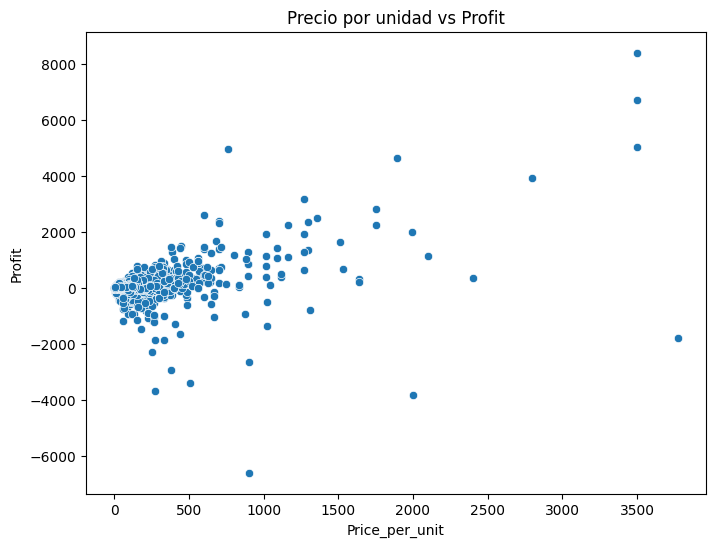

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Price_per_unit', y='Profit')
plt.title("Precio por unidad vs Profit")
plt.show()

##Estacionalidad

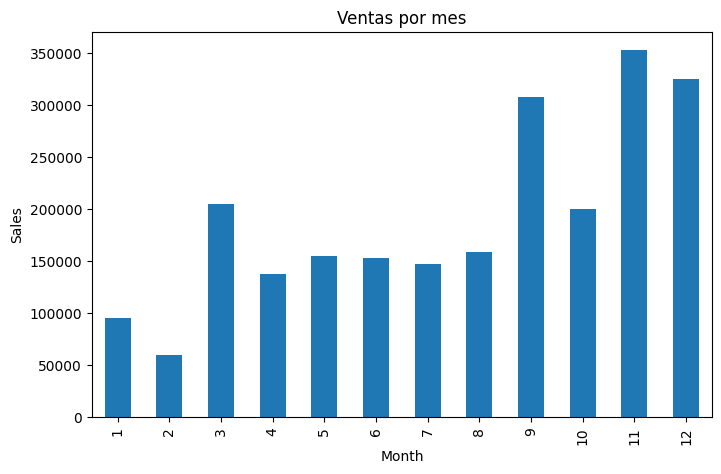

In [57]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
sales_month = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(8,5)) #graficando ventas por mes
sales_month.plot(kind='bar')
plt.title("Ventas por mes")
plt.ylabel("Sales")
plt.show()

## Ventas vs Ganancia por Producto

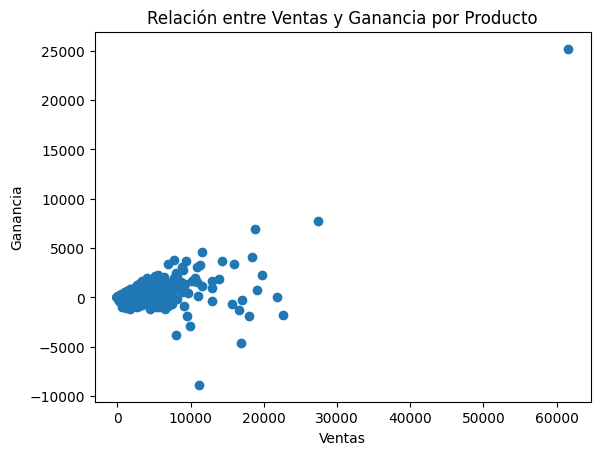

In [59]:
ventas_productos = df.groupby('Product Name')[['Sales','Profit']].sum()

plt.figure()
plt.scatter(ventas_productos['Sales'], ventas_productos['Profit'])

plt.title("Relación entre Ventas y Ganancia por Producto")
plt.xlabel("Ventas")
plt.ylabel("Ganancia")

plt.show()

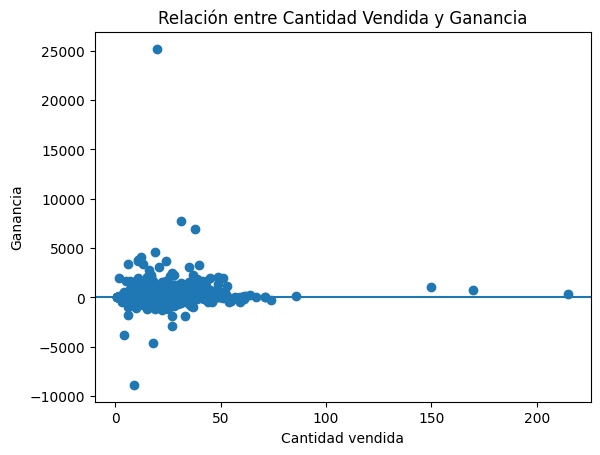

In [61]:
cantidad_ganancia = df.groupby('Product Name')[['Quantity','Profit']].sum()

plt.figure()

plt.scatter(cantidad_ganancia['Quantity'], cantidad_ganancia['Profit'])

plt.title("Relación entre Cantidad Vendida y Ganancia")
plt.xlabel("Cantidad vendida")
plt.ylabel("Ganancia")

plt.axhline(0)  # línea para separar ganancias y pérdidas

plt.show()

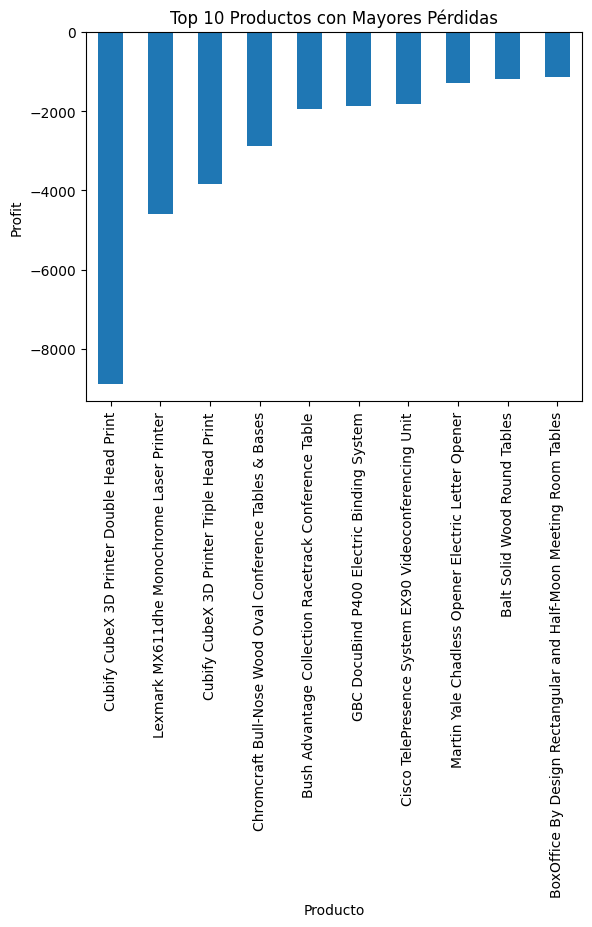

In [75]:
top_perdidas = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

plt.figure()

top_perdidas.plot(kind='bar')

plt.title("Top 10 Productos con Mayores Pérdidas")
plt.xlabel("Producto")
plt.ylabel("Profit")

plt.show()

##7. Insights

- Se identifican productos con altos volúmenes de venta en cantidad que, a pesar de su rotación, generan pérdidas para la empresa. Esto podría indicar precios insuficientes, descuentos elevados o altos costos asociados a estos productos.
- Un grupo reducido de productos concentra la mayor rentabilidad (Pareto)

##8. Conclusiones
---
- La categoría 'Technology' genera más ventas y profit.
- La región 'West' es la que más vende, seguida por 'East'.
- Los productos de menor precio tienen alto volumen pero menor profit.
- Se observa estacionalidad en meses como noviembre y diciembre.
- Se identificaron productos específicos que generan pérdidas acumuladas para la empresa. Estos productos deberían revisarse en términos de estrategia de precios, costos logísticos o descuentos aplicados.